In [1]:
# Importar librerías
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Dropout

# Generar datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Dividir datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [2]:
# Construir modelo de red neuronal
model = Sequential()
model.add(Dense(50, input_dim=20, activation='relu'))  # Capa oculta con 50 neuronas y función de activación ReLU
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # Capa de salida con una neurona para clasificación binaria y función de activación sigmoide

# Compilar modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
# Entrenar modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5537 - loss: 0.7209 - val_accuracy: 0.6050 - val_loss: 0.6451
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6650 - loss: 0.6072 - val_accuracy: 0.7150 - val_loss: 0.5625
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7475 - loss: 0.5246 - val_accuracy: 0.7650 - val_loss: 0.5055
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7887 - loss: 0.4691 - val_accuracy: 0.7850 - val_loss: 0.4665
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8300 - loss: 0.4328 - val_accuracy: 0.8100 - val_loss: 0.4353
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8475 - loss: 0.4042 - val_accuracy: 0.8200 - val_loss: 0.4162
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8525 - loss: 0.3774 - val_accuracy: 0.8350 - val_loss: 0.4008
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8662 - loss: 0.3534 - val_accuracy: 0.8450 - val_loss

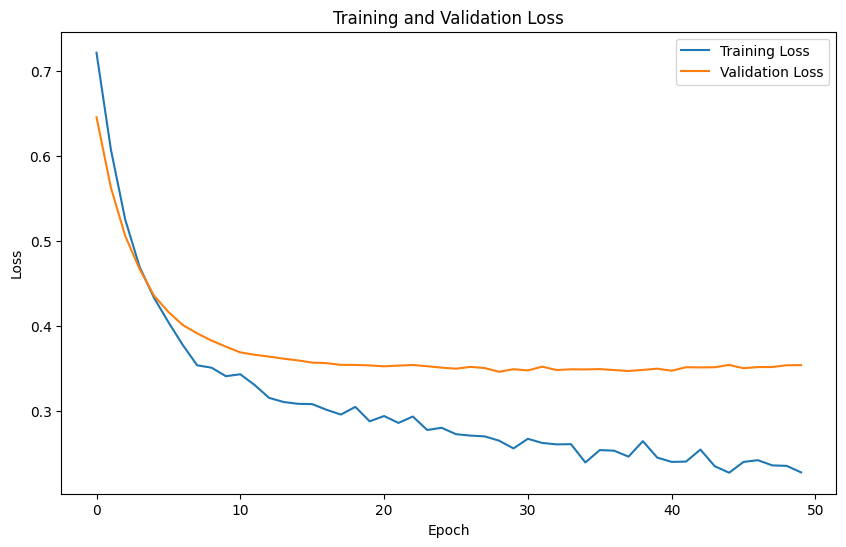

In [4]:
# Graficar función de costo durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [5]:


# Evaluar modelo
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_test, y_pred))



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        93
           1       0.90      0.85      0.88       107

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



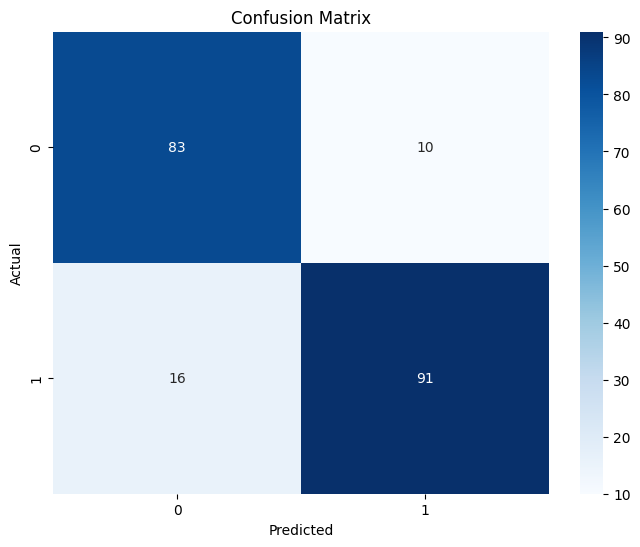

In [6]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Predecir en conjunto de prueba
y_predt = best_model.predict(X_train)

# Evaluar modelo
accuracy = accuracy_score(y_train, y_predt)
print("Best Model Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_train, y_predt))

25/25 [==============================] - 0s 1ms/step
Best Model Accuracy: 0.91875
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       407
           1       0.92      0.91      0.92       393

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800

